# Educational Data Mining of Learning Strategies and Programming Concept Comprehension
**BSc AI Thesis** s1088428  
**Research question:** Which learning strategies are associated with better comprehension of programming concepts in introductory programming courses?

## Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import (StratifiedKFold, KFold,
                                     cross_validate, train_test_split)
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay,
                             confusion_matrix, f1_score,
                             precision_score, recall_score,
                             mean_absolute_error, r2_score)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency, pointbiserialr
import statsmodels.api as sm
!pip install prince
import prince

## 1. Load Data

Two files are needed per cohort year:
- **Answers file** - answer choices (A/B/C/D/E) per question plus survey responses
- **Points file** - scores per question (0/1 for MCQ, fractional for some questions)

Both files use the same anonymised student ID (`Student number`) for merging.

In [38]:
from google.colab import files

print("Upload P1_2425_C1_Answers_Anon.csv")
ans_2425 = pd.read_csv(next(iter(files.upload())))
ans_2425.columns = ans_2425.columns.astype(str)
ans_2425 = ans_2425.map(lambda x: x.upper() if isinstance(x, str) else x)

print("\nUpload P1_2425_C1_Points_Anon.csv")
pts_2425 = pd.read_csv(next(iter(files.upload())))
pts_2425.columns = pts_2425.columns.astype(str)

print("\nUpload P1_2526_C1_Answers_Anon.csv")
ans_2526 = pd.read_csv(next(iter(files.upload())))
ans_2526.columns = ans_2526.columns.astype(str)
ans_2526 = ans_2526.map(lambda x: x.upper() if isinstance(x, str) else x)

print("\nUpload P1_2526_C1_Points_Anon.csv")
pts_2526 = pd.read_csv(next(iter(files.upload())))
pts_2526.columns = pts_2526.columns.astype(str)

print(f"\n2425 - Answers: {ans_2425.shape} | Points: {pts_2425.shape}")
print(f"2526 — Answers: {ans_2526.shape} | Points: {pts_2526.shape}")

Upload P1_2425_C1_Answers_Anon.csv


Saving P1_2425_C1_Answers_Anon.csv to P1_2425_C1_Answers_Anon (1).csv

Upload P1_2425_C1_Points_Anon.csv


Saving P1_2425_C1_Points_Anon.csv to P1_2425_C1_Points_Anon (1).csv

Upload P1_2526_C1_Answers_Anon.csv


Saving P1_2526_C1_Answers_Anon.csv to P1_2526_C1_Answers_Anon (1).csv

Upload P1_2526_C1_Points_Anon.csv


Saving P1_2526_C1_Points_Anon.csv to P1_2526_C1_Points_Anon (1).csv

2425 - Answers: (184, 42) | Points: (206, 55)
2526 — Answers: (127, 34) | Points: (143, 46)


## 2. Preprocessing

Students must have consented (Q49/Q38 = 'A') and answered at least
one survey question.

Likert responses A-E are mapped to integers 1-5. Q52/Q41 (multi-select strategies)
is parsed into binary columns.

Skill improvement is post minus pre self-assessed level.

In [39]:
letter_map    = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
strategy_info = {
    'used_slides':            'A',
    'used_extra_ex':          'B',
    'used_literature':        'C',
    'used_lovelace':          'D',
    'used_lectures':          'E',
    'used_practice_sessions': 'F',
}

def preprocess_survey(df, consent_col, skill_before_col, skill_after_col,
                      strategies_col, lecture_col, practice_col,
                      extra_strategies=None):
    """Filter, rename, encode and parse survey data."""
    df = df[
        (df[consent_col] == 'A') &
        (df[skill_before_col].notna() | df[skill_after_col].notna())
    ].copy()

    id_col = df.columns[0]
    df = df[[id_col, skill_before_col, skill_after_col,
             strategies_col, lecture_col, practice_col]].rename(columns={
        id_col:            'student_id',
        skill_before_col:  'skill_before',
        skill_after_col:   'skill_after',
        strategies_col:    'strategies',
        lecture_col:       'lecture_attendance',
        practice_col:      'practice_attendance',
    })

    for col in ['skill_before', 'skill_after',
                'lecture_attendance', 'practice_attendance']:
        df[col] = df[col].map(letter_map)

    df['strategies'] = df['strategies'].fillna('')
    strats = {**strategy_info, **(extra_strategies or {})}
    for col, letter in strats.items():
        df[col] = df['strategies'].str.contains(letter, case=False).astype(int)

    df['skill_improvement'] = df['skill_after'] - df['skill_before']
    df['n_strategies']      = df[list(strats)].sum(axis=1)

    df = df.dropna(subset=['skill_before', 'skill_after',
                            'lecture_attendance', 'practice_attendance'])
    df = df.drop(columns=['strategies']).reset_index(drop=True)
    df['student_id'] = df['student_id'].astype(str)
    return df

# dataset 2425 (Programming 1 year 2024/2025)
survey_2425 = preprocess_survey(
    ans_2425,
    consent_col='49', skill_before_col='50', skill_after_col='51',
    strategies_col='52', lecture_col='53', practice_col='54'
)
survey_2425['year'] = '2425'
print(f"2425: {len(survey_2425)} students after consent and cleaning")

# dataset 2526 (Programming 1 year 2025/2026) (has 3 extra strategies G, H, I)
survey_2526 = preprocess_survey(
    ans_2526,
    consent_col='38', skill_before_col='39', skill_after_col='40',
    strategies_col='41', lecture_col='42', practice_col='43',
    extra_strategies={
        'used_summaries': 'G',
        'used_peers':     'H',
        'used_feedback':  'I',
    }
)
survey_2526['year'] = '2526'
# fill G/H/I as 0 for 2425 students
for col in ['used_summaries', 'used_peers', 'used_feedback']:
    survey_2425[col] = 0

print(f"2526: {len(survey_2526)} students after consent and cleaning")

2425: 139 students after consent and cleaning
2526: 87 students after consent and cleaning


## 3. Compute Concept Scores

Each concept score is the proportion of questions answered correctly within that
concept group (0.0 = none correct, 1.0 = all correct). Values of -1 indicate absent students
and are treated as missing. Column 26 in the 2425 file has a maximum of 2.0
(partial credit) and is normalised before computing the mean. Columns 1 and 2
in the 2526 file are raw points (max 6.0 and 4.0 respectively) and are similarly
normalised.

In [40]:
def compute_concept_scores(pts_df, sections, id_col='Student number',
                           normalise=None):
    """Compute mean proportion correct per concept group."""
    pts = pts_df.copy().replace(-1, np.nan)
    pts.columns = pts.columns.astype(str)

    # normalise columns that have raw points instead of 0/1
    if normalise:
        for col, max_val in normalise.items():
            if col in pts.columns:
                pts[col] = pts[col] / max_val

    concept_names = [s[0] for s in sections]
    for concept, cols in sections:
        available = [c for c in cols if c in pts.columns]
        pts[concept] = pts[available].mean(axis=1)

    pts['student_id'] = pts[id_col].astype(str)
    return pts[['student_id'] + concept_names], concept_names

# 2425 concept mapping
sections_2425 = [
    ("operations_and_types",      ['1','2','3','4','5']),
    ("boolean_operations",        ['6','7','8','9']),
    ("if_statements",             ['10','11','12','13','14','15']),
    ("list_operations",           ['16','17','18','19','20']),
    ("functions",                 ['21','22','23','24']),
    ("for_loops",                 ['25','26']),
    ("theoretical_with_examples", ['27','28','29','30']),
    ("theoretical",               ['31','32','33','34','35']),
    ("io_read_write",             ['36','37','38','39','40']),
]
scores_2425, concept_names_2425 = compute_concept_scores(
    pts_2425, sections_2425,
    normalise={'26': 2.0}   # column 26 has max 2.0
)

# 2526 concept mapping
sections_2526 = [
    ("operations_and_types",      ['1']),
    ("boolean_operations",        ['2']),
    ("if_statements",             ['3','4','5','6','7','8']),
    ("list_operations",           ['9','10','11']),
    ("for_loops",                 ['12','13','14']),
    ("functions",                 ['15','16','17','18','19']),
    ("io_read_write",             ['20','21','22','23','24']),
    ("theoretical_with_examples", ['25','26','27','28']),
    ("theoretical",               ['29','30','31','32','33']),
]
scores_2526, concept_names_2526 = compute_concept_scores(
    pts_2526, sections_2526,
    normalise={'1': 6.0, '2': 4.0}  # raw points in these columns
)

# merge survey and scores per year
merged_2425 = survey_2425.merge(scores_2425, on='student_id')
merged_2526 = survey_2526.merge(scores_2526, on='student_id')

print(f"2425 merged: {len(merged_2425)} students")
print(f"2526 merged: {len(merged_2526)} students")

print("\n2425 concept scores:")
print(merged_2425[concept_names_2425].describe().round(2))
print("\n2526 concept scores:")
print(merged_2526[concept_names_2526].describe().round(2))

2425 merged: 139 students
2526 merged: 87 students

2425 concept scores:
       operations_and_types  boolean_operations  if_statements  \
count                139.00              139.00         139.00   
mean                   0.96                0.89           0.79   
std                    0.09                0.17           0.21   
min                    0.40                0.25           0.17   
25%                    1.00                0.75           0.67   
50%                    1.00                1.00           0.83   
75%                    1.00                1.00           1.00   
max                    1.00                1.00           1.00   

       list_operations  functions  for_loops  theoretical_with_examples  \
count           139.00     139.00     139.00                     139.00   
mean              0.62       0.83       0.48                       0.87   
std               0.26       0.20       0.30                       0.17   
min               0.00       0.0

## 4. Combine Datasets

The two cohorts are combined into one dataset. The 2526 cohort introduced three
additional strategy options (G: summaries, H: peers, I: feedback) which were not
available to 2425 students. These are set to 0 for all 2425 students.

In [41]:
all_concepts = sorted(set(concept_names_2425) & set(concept_names_2526))

all_strategy_cols = list(strategy_info.keys()) + \
                    ['used_summaries', 'used_peers', 'used_feedback']
all_labels = ['Slides', 'Extra ex.', 'Literature', 'Lovelace', 'Lectures',
              'Practice', 'Summaries', 'Peers', 'Feedback']

# add missing concept cols as NaN so concat works
for concept in all_concepts:
    if concept not in merged_2425.columns:
        merged_2425[concept] = np.nan
    if concept not in merged_2526.columns:
        merged_2526[concept] = np.nan

merged = pd.concat([merged_2425, merged_2526], ignore_index=True)

# global aliases used throughout the rest of the notebook
strategy_cols = all_strategy_cols
labels        = all_labels
concept_names = all_concepts

print(f"\nCombined: {len(merged)} students total")
print(merged['year'].value_counts())


Combined: 226 students total
year
2425    139
2526     87
Name: count, dtype: int64


## 5. Exploratory Data Analysis

In [42]:
print("Descriptive Statistics - Combined Dataset")
print(merged[['skill_before', 'skill_after', 'skill_improvement',
              'lecture_attendance', 'practice_attendance']].describe().round(2))

Descriptive Statistics - Combined Dataset
       skill_before  skill_after  skill_improvement  lecture_attendance  \
count        226.00       226.00             226.00              226.00   
mean           2.08         3.08               1.01                3.57   
std            1.25         0.88               0.79                1.53   
min            1.00         1.00              -1.00                1.00   
25%            1.00         2.00               0.00                2.00   
50%            2.00         3.00               1.00                4.00   
75%            3.00         4.00               2.00                5.00   
max            5.00         5.00               3.00                5.00   

       practice_attendance  
count               226.00  
mean                  2.53  
std                   1.47  
min                   1.00  
25%                   1.00  
50%                   2.00  
75%                   4.00  
max                   5.00  


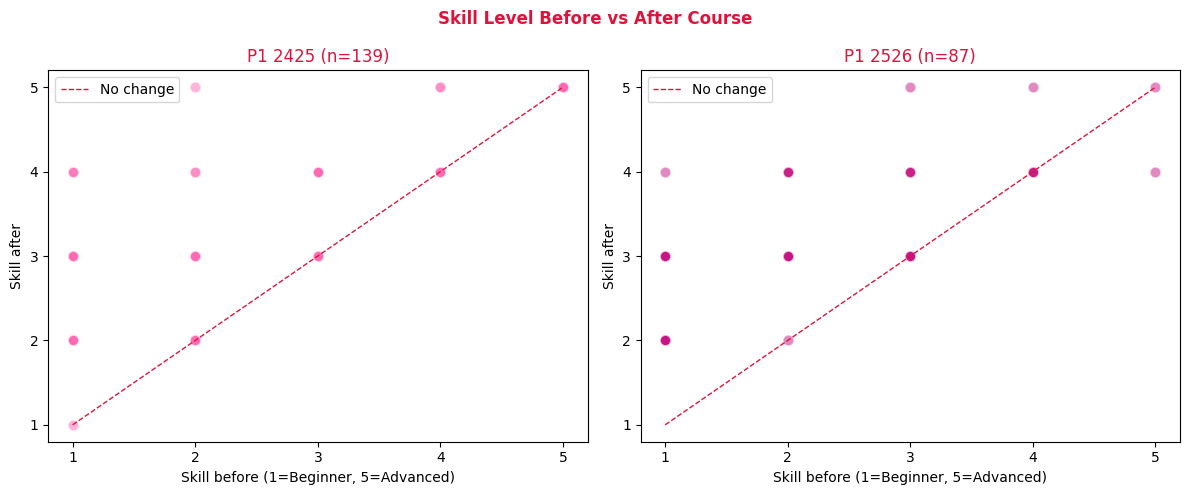

P1 2425 - before: 2.19 | after: 3.16 | gain: 0.96
P1 2526 - before: 1.89 | after: 2.97 | gain: 1.08


In [43]:
# skill scatterplot per year
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Skill Level Before vs After Course',
             color='crimson', fontweight='bold')
for ax, year, color in zip(axes, ['2425','2526'],
                           ['hotpink','mediumvioletred']):
    sub = merged[merged['year'] == year]
    ax.scatter(sub['skill_before'], sub['skill_after'],
               color=color, alpha=0.5, edgecolors='white', s=60)
    ax.plot([1,5],[1,5], color='crimson', linestyle='--',
            linewidth=1, label='No change')
    ax.set_title(f'P1 {year} (n={len(sub)})', color='crimson')
    ax.set_xlabel('Skill before (1=Beginner, 5=Advanced)')
    ax.set_ylabel('Skill after')
    ax.set_xticks(range(1,6)); ax.set_yticks(range(1,6))
    ax.legend()
plt.tight_layout(); plt.show()

for year in ['2425','2526']:
    s = merged[merged['year'] == year]
    print(f"P1 {year} - before: {s['skill_before'].mean():.2f} | "
          f"after: {s['skill_after'].mean():.2f} | "
          f"gain: {s['skill_improvement'].mean():.2f}")

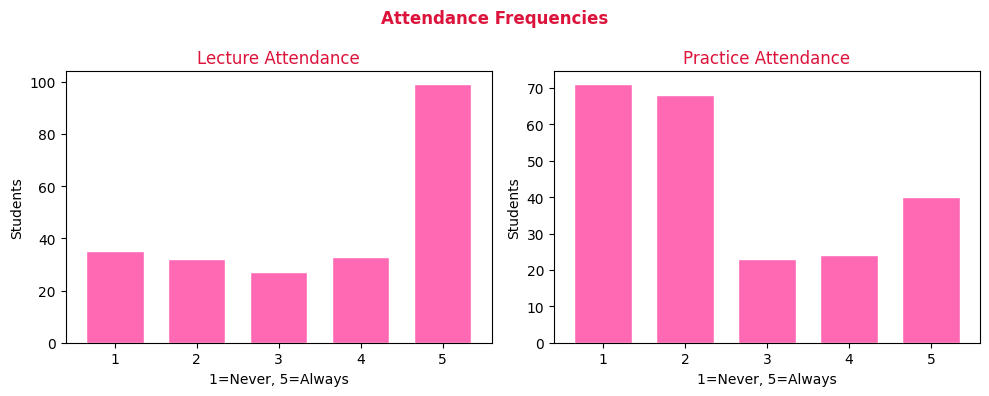

In [44]:
# attendance
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Attendance Frequencies', fontweight='bold', color='crimson')
for ax, col, title in zip(
    axes,
    ['lecture_attendance', 'practice_attendance'],
    ['Lecture Attendance', 'Practice Attendance']
):
    merged[col].value_counts().reindex(range(1,6), fill_value=0).plot.bar(
        ax=ax, color='hotpink', edgecolor='white', width=0.7)
    ax.set_title(title, color='crimson')
    ax.set_xlabel('1=Never, 5=Always'); ax.set_ylabel('Students')
    ax.set_xticklabels(range(1,6), rotation=0)
plt.tight_layout(); plt.show()

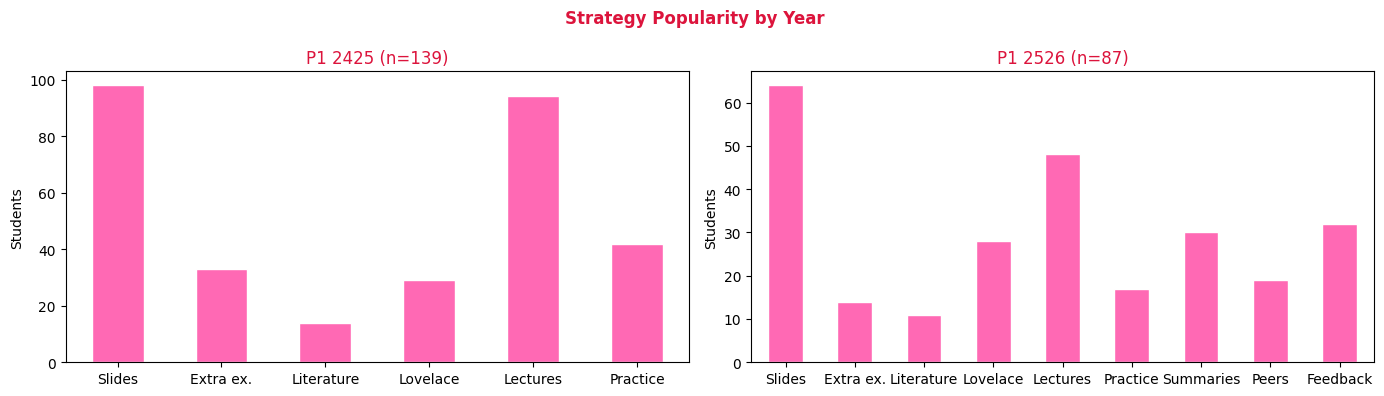

In [45]:
# strategy popularity by year
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Strategy Popularity by Year', color='crimson', fontweight='bold')
for ax, year in zip(axes, ['2425','2526']):
    sub  = merged[merged['year'] == year]
    cols = strategy_cols[:6] if year == '2425' else strategy_cols
    lbs  = labels[:6]        if year == '2425' else labels
    sub[cols].sum().set_axis(lbs).plot.bar(
        ax=ax, color='hotpink', edgecolor='white', rot=0)
    ax.set_title(f'P1 {year} (n={len(sub)})', color='crimson')
    ax.set_ylabel('Students')
plt.tight_layout(); plt.show()

High attendance students: 139 / 226


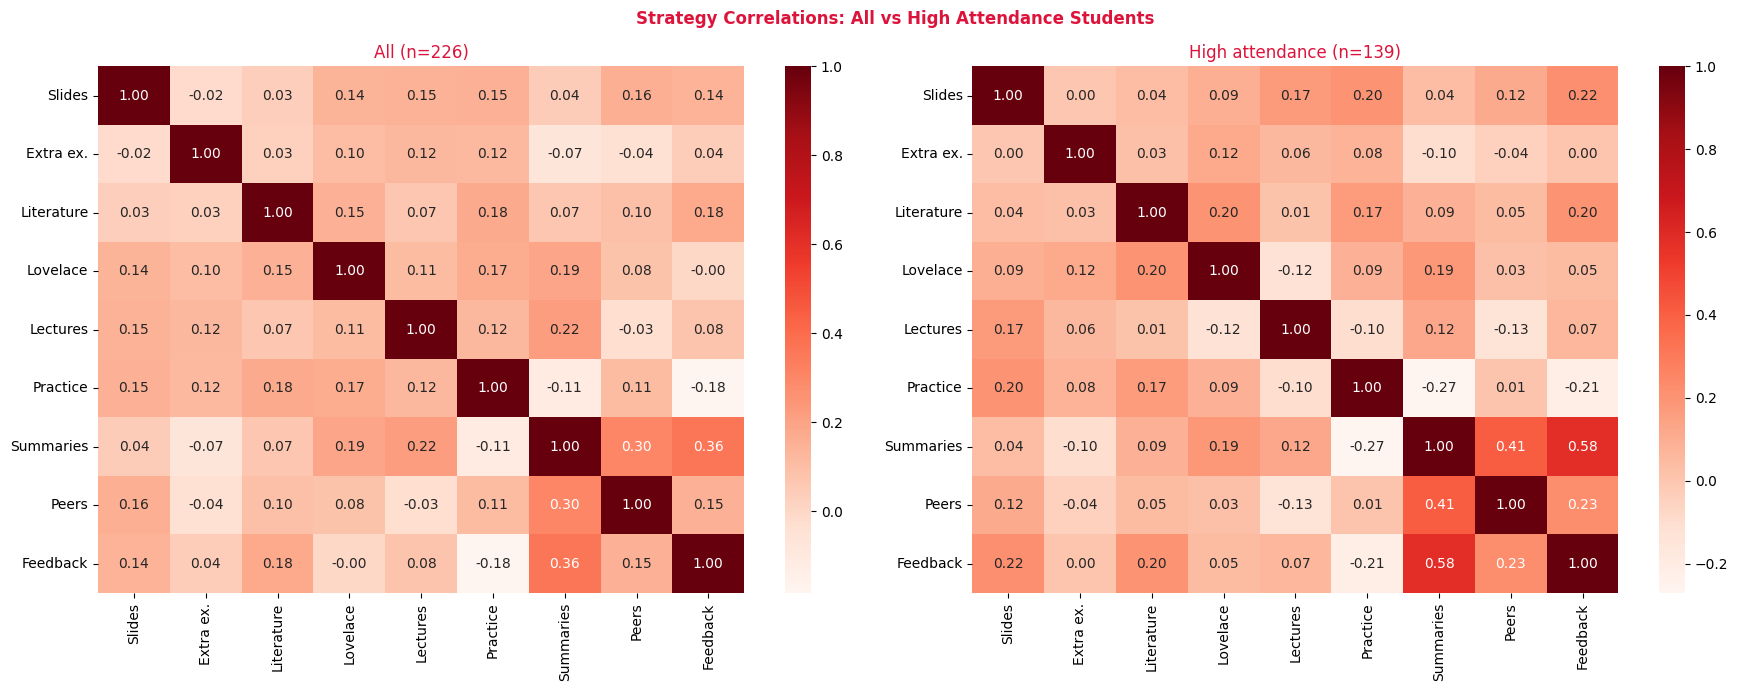

In [46]:
# strategy co-occurrence and high attendance comparison
high_att = merged[
    (merged['lecture_attendance'] >= 4) |
    (merged['practice_attendance'] >= 4)
]
print(f"High attendance students: {len(high_att)} / {len(merged)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Strategy Correlations: All vs High Attendance Students',
             color='crimson', fontweight='bold')
for ax, data, title in zip(
    axes,
    [merged, high_att],
    [f'All (n={len(merged)})', f'High attendance (n={len(high_att)})']
):
    sns.heatmap(data[strategy_cols].corr(), annot=True, fmt='.2f',
                xticklabels=labels, yticklabels=labels,
                cmap='Reds', cbar=True, ax=ax)
    ax.set_title(title, color='crimson')
plt.tight_layout(); plt.show()

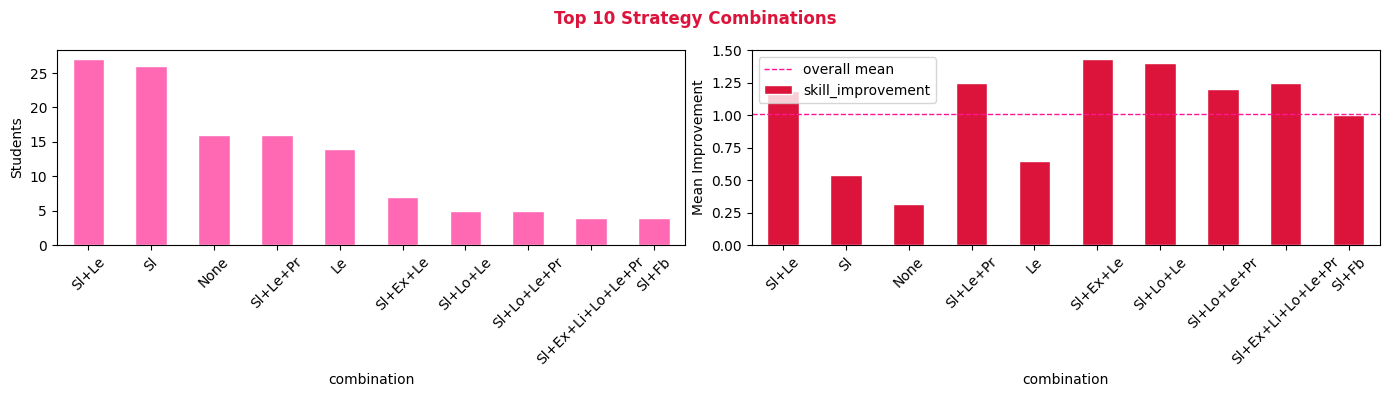

In [47]:
# strategy combinations
combo_short = dict(zip(strategy_cols,
    ['Sl','Ex','Li','Lo','Le','Pr','Su','Pe','Fb']))

merged['combination'] = merged.apply(
    lambda r: '+'.join(s for c, s in combo_short.items() if r[c] == 1) or 'None',
    axis=1)
top10 = merged['combination'].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Top 10 Strategy Combinations', color='crimson', fontweight='bold')
top10.plot.bar(ax=axes[0], color='hotpink', edgecolor='white')
axes[0].set_ylabel('Students'); axes[0].tick_params(axis='x', rotation=45)
(merged.groupby('combination')['skill_improvement'].mean()
 .reindex(top10.index).plot.bar(ax=axes[1], color='crimson', edgecolor='white'))
axes[1].axhline(merged['skill_improvement'].mean(), color='deeppink',
                linestyle='--', linewidth=1, label='overall mean')
axes[1].set_ylabel('Mean Improvement'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

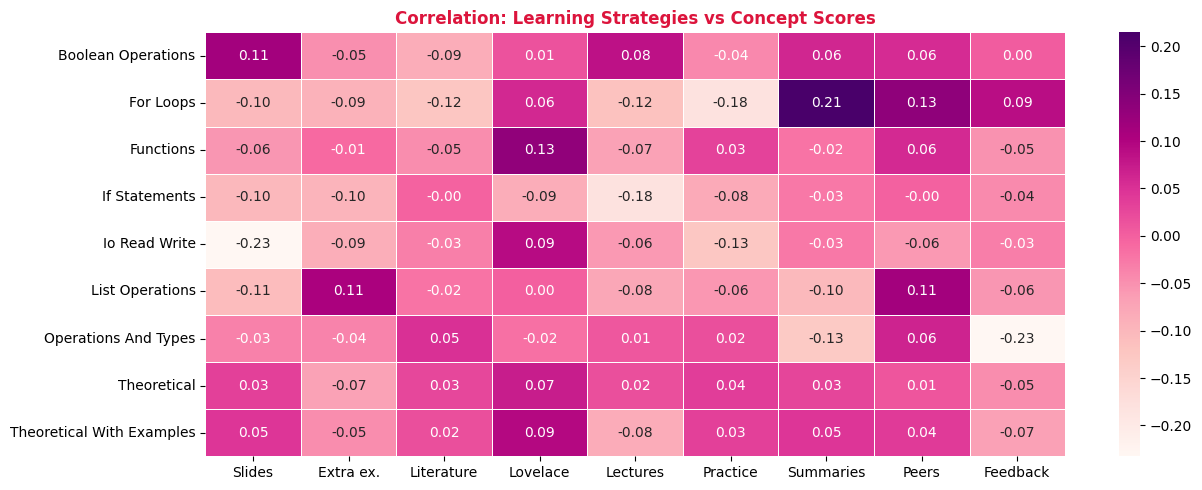

In [48]:
# strategy vs concept correlation heatmap
corr = merged[strategy_cols + concept_names].corr(numeric_only=True)
plt.figure(figsize=(13, 5))
sns.heatmap(corr.loc[strategy_cols, concept_names].T,
            annot=True, fmt='.2f',
            xticklabels=labels,
            yticklabels=[c.replace('_',' ').title() for c in concept_names],
            cmap='RdPu', linewidths=0.5)
plt.title('Correlation: Learning Strategies vs Concept Scores',
          color='crimson', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Multiple Correspondence Analysis (MCA)

MCA examines the structure of learning strategy variables, similar to PCA for binary/categorical data. A Benzécri correction is used to adjust for dimensionality inflation caused by binary encoding. The scree plot shows the number of components required to explain 70% of total inertia.

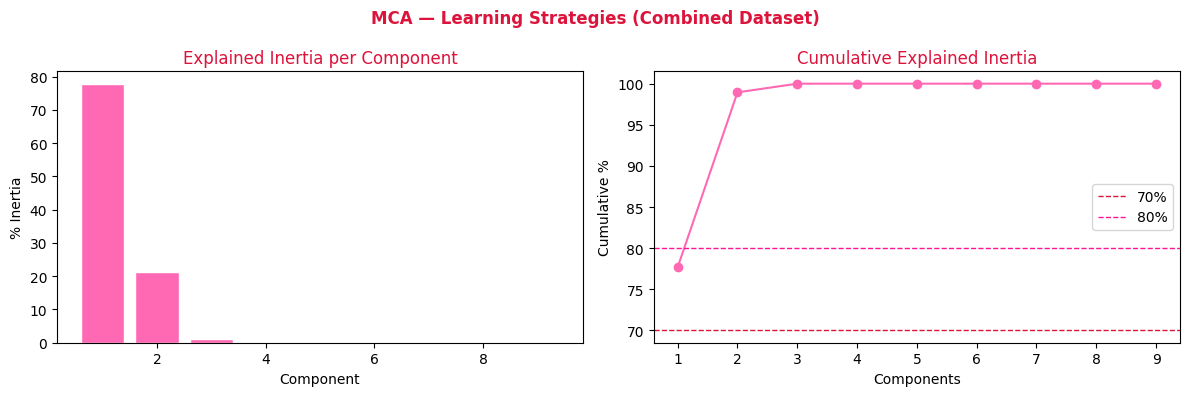

Components for 70% inertia: 1 / 9 variables


In [49]:
strategy_data = merged[strategy_cols].astype(str)

mca = prince.MCA(
    n_components=len(strategy_cols), n_iter=3,
    correction='benzecri', random_state=42
).fit(strategy_data)

explained  = mca.eigenvalues_ / mca.eigenvalues_.sum() * 100
cumulative = explained.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('MCA — Learning Strategies (Combined Dataset)',
             color='crimson', fontweight='bold')
axes[0].bar(range(1, len(explained)+1), explained,
            color='hotpink', edgecolor='white')
axes[0].set_title('Explained Inertia per Component', color='crimson')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('% Inertia')
axes[1].plot(range(1, len(cumulative)+1), cumulative,
             marker='o', color='hotpink')
axes[1].axhline(70, color='crimson', linestyle='--', linewidth=1, label='70%')
axes[1].axhline(80, color='deeppink', linestyle='--', linewidth=1, label='80%')
axes[1].set_title('Cumulative Explained Inertia', color='crimson')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative %')
axes[1].legend()
plt.tight_layout(); plt.show()

n_70 = int((cumulative < 70).sum()) + 1
print(f"Components for 70% inertia: {n_70} / {len(strategy_cols)} variables")

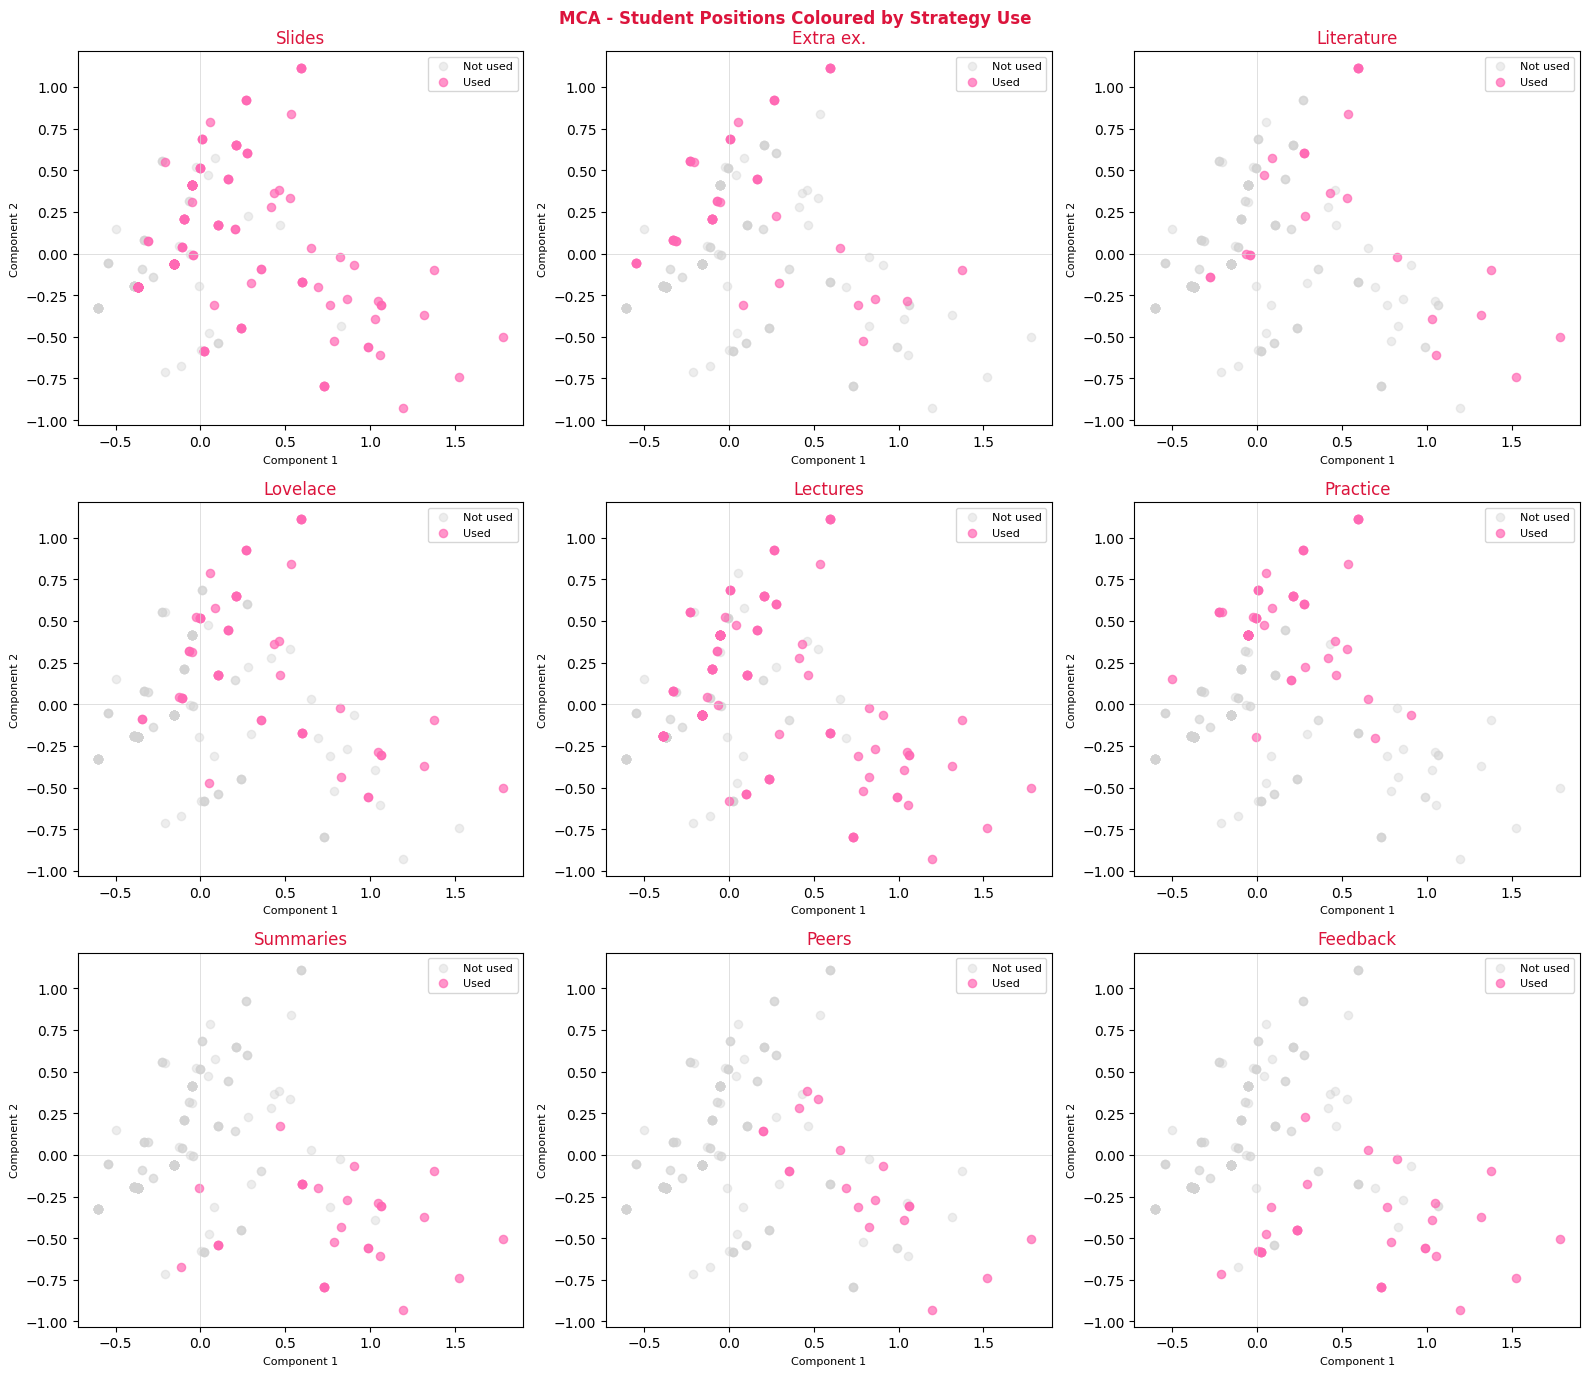

In [50]:
coords = mca.transform(strategy_data)

# coloured by strategy use
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle('MCA - Student Positions Coloured by Strategy Use',
             color='crimson', fontweight='bold')
for ax, col, label in zip(axes.flatten(), strategy_cols, labels):
    not_u = coords[merged[col] == 0]
    used  = coords[merged[col] == 1]
    ax.scatter(not_u.iloc[:,0], not_u.iloc[:,1],
               color='lightgray', alpha=0.4, s=35, label='Not used')
    ax.scatter(used.iloc[:,0],  used.iloc[:,1],
               color='hotpink',  alpha=0.7, s=35, label='Used')
    ax.axhline(0, color='lightgray', linewidth=0.5)
    ax.axvline(0, color='lightgray', linewidth=0.5)
    ax.set_title(label, color='crimson'); ax.legend(fontsize=8)
    ax.set_xlabel('Component 1', fontsize=8)
    ax.set_ylabel('Component 2', fontsize=8)
plt.tight_layout(); plt.show()

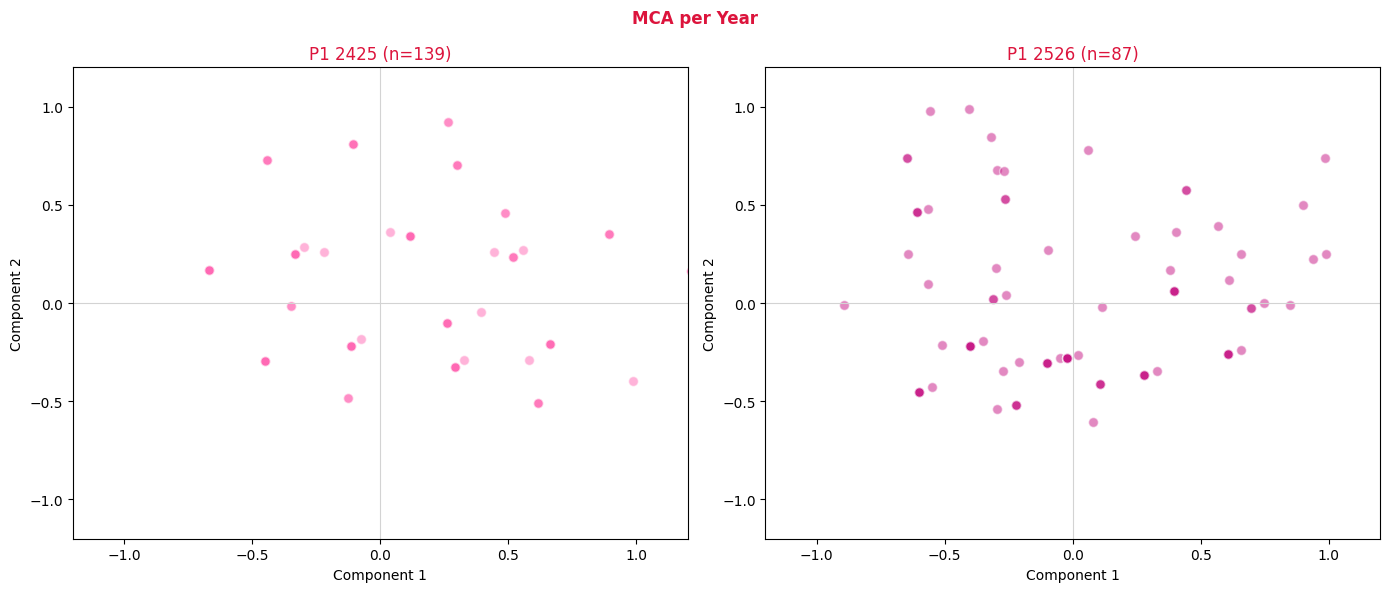

In [51]:
# per-year MCA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('MCA per Year', color='crimson', fontweight='bold')
for ax, year, color in zip(axes, ['2425','2526'], ['hotpink','mediumvioletred']):
    sub = merged[merged['year']==year][strategy_cols].fillna(0).astype(str)
    c   = prince.MCA(n_components=min(len(strategy_cols), len(sub)-1),
                     n_iter=3, correction='benzecri', random_state=42
                     ).fit(sub).transform(sub)
    ax.scatter(c.iloc[:,0], c.iloc[:,1], color=color, alpha=0.5,
               edgecolors='white', s=50)
    ax.axhline(0, color='lightgray', linewidth=0.8)
    ax.axvline(0, color='lightgray', linewidth=0.8)
    ax.set_title(f'P1 {year} (n={len(sub)})', color='crimson')
    ax.set_xlabel('Component 1'); ax.set_ylabel('Component 2')
    ax.set_xlim([-1.2,1.2])
    ax.set_ylim([-1.2,1.2])
plt.tight_layout(); plt.show()

## 7. Model 1 - Logistic Regression (Pass/Fail per Concept)

Logistic regression predicts whether a student passes each programming concept,
defined as correctly answering at least 50% of the questions in that concept group.

**Predictors:** seven binary strategy variables (slides, extra exercises, literature,
Lovelace, summaries, peers, feedback) plus lecture and practice attendance (nine predictors in total) min-max scaled to ensure comparability across features.

**Class weighting:** `class_weight='balanced'` corrects for class imbalance. Most
students pass most concepts, so without weighting the model would predict "pass"
for everyone and achieve high accuracy without learning anything useful.

**Regularisation:** L1 and L2 penalties are compared per concept using 5-fold
stratified cross-validation on the training set. The penalty with the higher F1
macro is selected for each concept.

**Train/test split:** 80/20 stratified on year to preserve cohort balance.
Cross-validation runs on the training set; final metrics are reported on the
held-out test set.

**Metrics:** accuracy, precision, recall, F1 macro, ROC-AUC.

In [52]:
predictor_cols   = [c for c in strategy_cols
                    if c not in ['used_lectures', 'used_practice_sessions']] \
                    + ['lecture_attendance', 'practice_attendance']
predictor_labels = [l for l, c in zip(labels, strategy_cols)
                    if c not in ['used_lectures', 'used_practice_sessions']] \
                    + ['Lect. attend.', 'Prac. attend.']

X_full = merged[predictor_cols].fillna(0)

X_train_raw, X_test_raw, idx_train, idx_test = train_test_split(
    X_full, merged.index,
    test_size=0.2, random_state=42,
    stratify=merged['year']
)

scaler         = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)

y_train_all = merged.loc[idx_train]
y_test_all  = merged.loc[idx_test]

print(f"Train: {len(X_train_raw)} | Test: {len(X_test_raw)}")
print(f"Train year split: {y_train_all['year'].value_counts().to_dict()}")
print(f"Test year split:  {y_test_all['year'].value_counts().to_dict()}")

Train: 180 | Test: 46
Train year split: {'2425': 111, '2526': 69}
Test year split:  {'2425': 28, '2526': 18}


### 7.1 Multicollinearity Check (VIF)

      feature  VIF
Lect. attend. 6.11
Prac. attend. 5.78
       Slides 3.28
    Summaries 1.77
     Lovelace 1.53
     Feedback 1.46
    Extra ex. 1.32
        Peers 1.25
   Literature 1.24


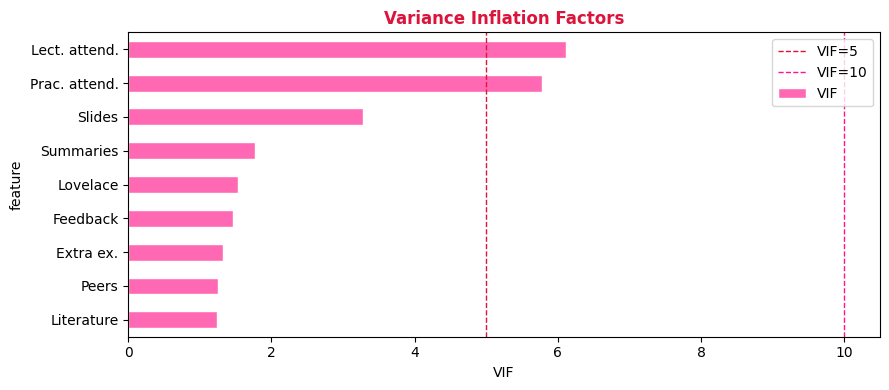

In [53]:
vif = pd.DataFrame({
    'feature': predictor_labels,
    'VIF': [variance_inflation_factor(X_full.values, i)
            for i in range(len(predictor_cols))]
}).sort_values('VIF', ascending=False)
print(vif.round(2).to_string(index=False))

plt.figure(figsize=(9, 4))
vif.sort_values('VIF').plot.barh(
    x='feature', y='VIF', color='hotpink',
    edgecolor='white', legend=False, ax=plt.gca())
plt.axvline(5,  color='crimson', linestyle='--', linewidth=1, label='VIF=5')
plt.axvline(10, color='deeppink', linestyle='--', linewidth=1, label='VIF=10')
plt.title('Variance Inflation Factors', color='crimson', fontweight='bold')
plt.xlabel('VIF'); plt.legend(); plt.tight_layout(); plt.show()

### 7.2 L1 vs L2 Regularisation - Model Selection

In [54]:
solvers  = {'l1': 'liblinear', 'l2': 'lbfgs'}
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring  = ['accuracy', 'precision_macro', 'recall_macro',
            'f1_macro', 'roc_auc']

penalty_selection = {}

for concept in concept_names:
    y_tr = (y_train_all[concept] >= 0.5).astype(int)
    if (y_tr.nunique() < 2 or y_tr.sum() < 5 or
            (len(y_tr) - y_tr.sum()) < 5):
        continue
    best_pen, best_f1 = 'l2', -1
    for pen in ['l1', 'l2']:
        res = cross_validate(
            LogisticRegression(penalty=pen, solver=solvers[pen],
                               class_weight='balanced', max_iter=1000),
            X_train_scaled, y_tr, cv=cv_strat, scoring=scoring)
        if res['test_f1_macro'].mean() > best_f1:
            best_f1, best_pen = res['test_f1_macro'].mean(), pen
    penalty_selection[concept] = best_pen

print("Selected penalty per concept:")
for c, p in penalty_selection.items():
    print(f"  {c:35s}  {p.upper()}")

Selected penalty per concept:
  boolean_operations                   L2
  for_loops                            L2
  if_statements                        L2
  io_read_write                        L2
  list_operations                      L2
  theoretical                          L2


### 7.3 Cross-Validated Performance (Training Set)

In [55]:
cv_results = {}
for concept, pen in penalty_selection.items():
    y_tr = (y_train_all[concept] >= 0.5).astype(int)
    res  = cross_validate(
        LogisticRegression(penalty=pen, solver=solvers[pen],
                           class_weight='balanced', max_iter=1000),
        X_train_scaled, y_tr, cv=cv_strat, scoring=scoring)
    cv_results[concept] = {
        'accuracy':  round(res['test_accuracy'].mean(), 3),
        'precision': round(res['test_precision_macro'].mean(), 3),
        'recall':    round(res['test_recall_macro'].mean(), 3),
        'f1':        round(res['test_f1_macro'].mean(), 3),
        'roc_auc':   round(res['test_roc_auc'].mean(), 3),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df.to_string())

                    accuracy  precision  recall     f1  roc_auc
boolean_operations     0.672      0.477   0.348  0.401    0.307
for_loops              0.556      0.524   0.521  0.515    0.532
if_statements          0.822      0.548   0.714  0.541    0.786
io_read_write          0.567      0.502   0.498  0.458    0.556
list_operations        0.494      0.519   0.520  0.491    0.526
theoretical            0.689      0.500   0.551  0.432    0.648


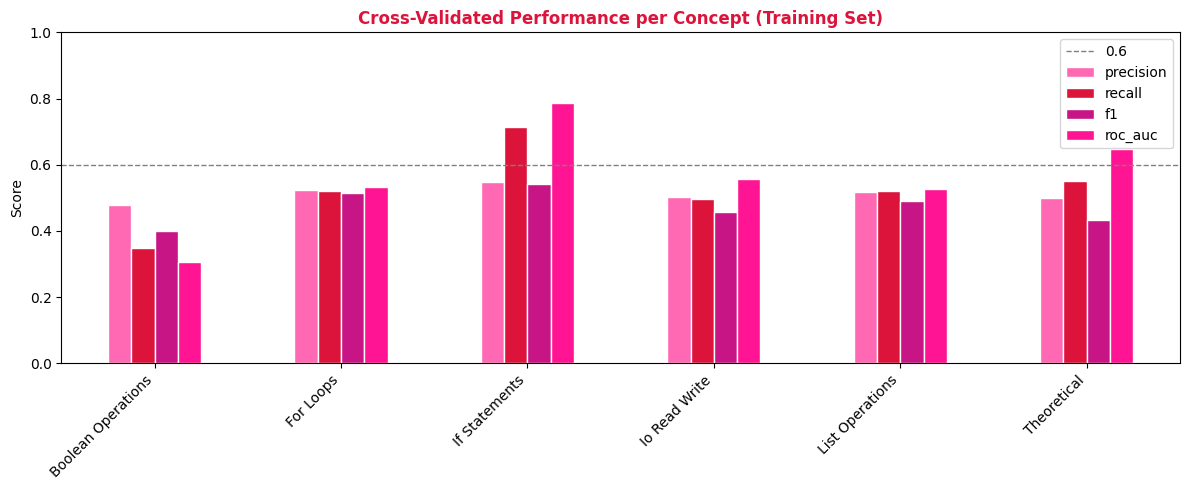

In [56]:
concept_labels_plot = [c.replace('_',' ').title() for c in cv_df.index]

cv_df[['precision','recall','f1','roc_auc']].plot.bar(
    color=['hotpink','crimson','mediumvioletred','deeppink'],
    edgecolor='white', figsize=(12, 5))
plt.title('Cross-Validated Performance per Concept (Training Set)',
          color='crimson', fontweight='bold')
plt.ylabel('Score'); plt.ylim(0, 1)
plt.xticks(range(len(concept_labels_plot)),
           concept_labels_plot, rotation=45, ha='right')
plt.axhline(0.6, color='gray', linestyle='--', linewidth=1, label='0.6')
plt.legend(); plt.tight_layout(); plt.show()

### 7.4 Test Set Evaluation

In [57]:
test_results = {}

for concept, pen in penalty_selection.items():
    y_tr   = (y_train_all[concept] >= 0.5).astype(int)
    y_te   = (y_test_all[concept]  >= 0.5).astype(int)
    if y_te.nunique() < 2:
        continue
    model  = LogisticRegression(penalty=pen, solver=solvers[pen],
                                class_weight='balanced', max_iter=1000)
    model.fit(X_train_scaled, y_tr)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    test_results[concept] = {
        'accuracy':  round((y_pred == y_te).mean(), 3),
        'precision': round(precision_score(y_te, y_pred,
                           average='macro', zero_division=0), 3),
        'recall':    round(recall_score(y_te, y_pred,
                           average='macro', zero_division=0), 3),
        'f1':        round(f1_score(y_te, y_pred,
                           average='macro', zero_division=0), 3),
        'roc_auc':   round(roc_auc_score(y_te, y_proba), 3),
    }
    print(f"\n{concept.replace('_',' ').title()}  [{pen.upper()}]")
    print(classification_report(y_te, y_pred,
                                target_names=['Fail','Pass'],
                                zero_division=0))

test_df = pd.DataFrame(test_results).T
print("\nTest set summary:")
print(test_df.to_string())


Boolean Operations  [L2]
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         2
        Pass       0.94      0.75      0.84        44

    accuracy                           0.72        46
   macro avg       0.47      0.38      0.42        46
weighted avg       0.90      0.72      0.80        46


For Loops  [L2]
              precision    recall  f1-score   support

        Fail       0.47      0.69      0.56        13
        Pass       0.85      0.70      0.77        33

    accuracy                           0.70        46
   macro avg       0.66      0.69      0.66        46
weighted avg       0.74      0.70      0.71        46


If Statements  [L2]
              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         1
        Pass       0.97      0.87      0.92        45

    accuracy                           0.85        46
   macro avg       0.49      0.43      0.46        46
weighted a

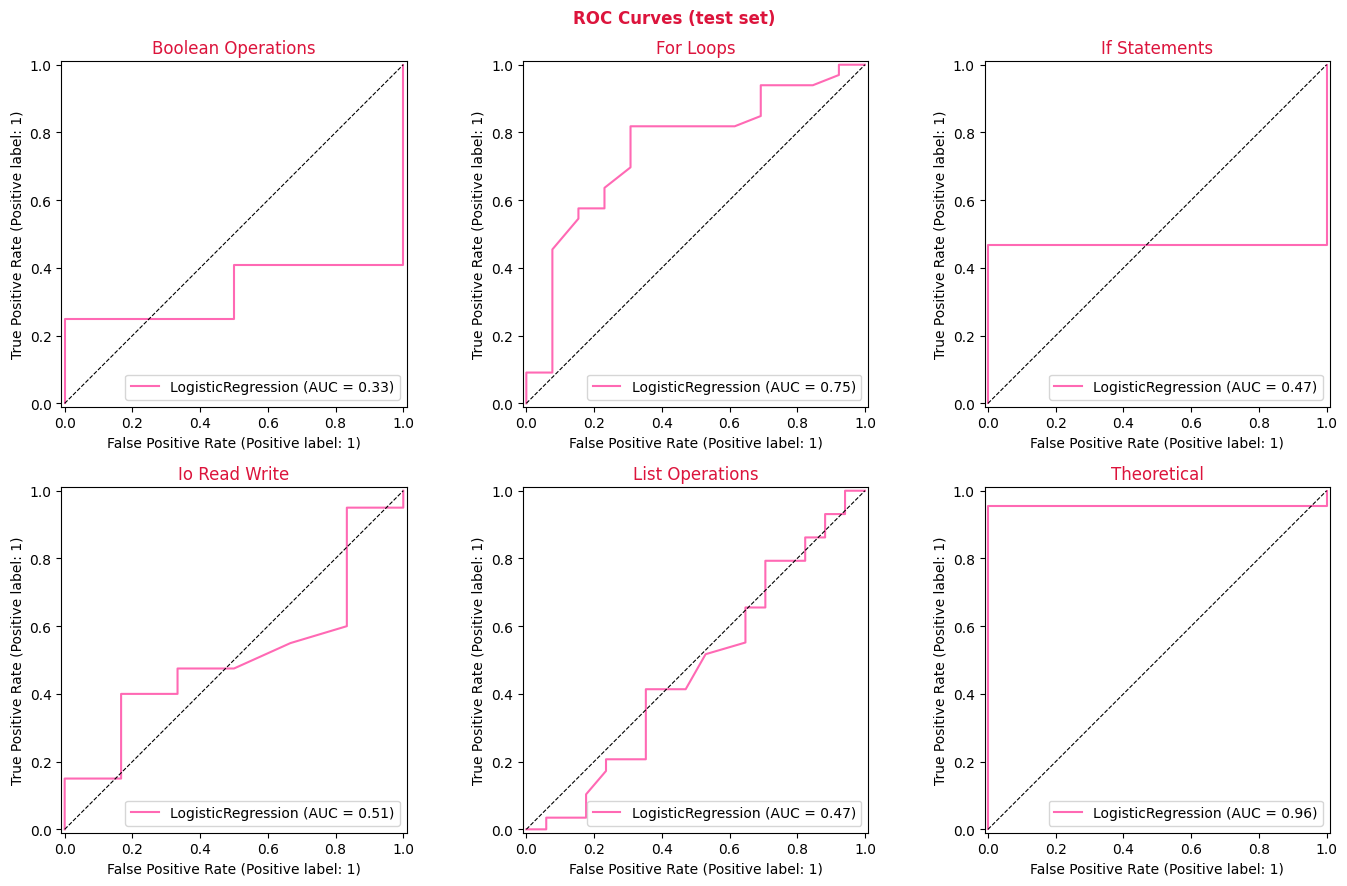

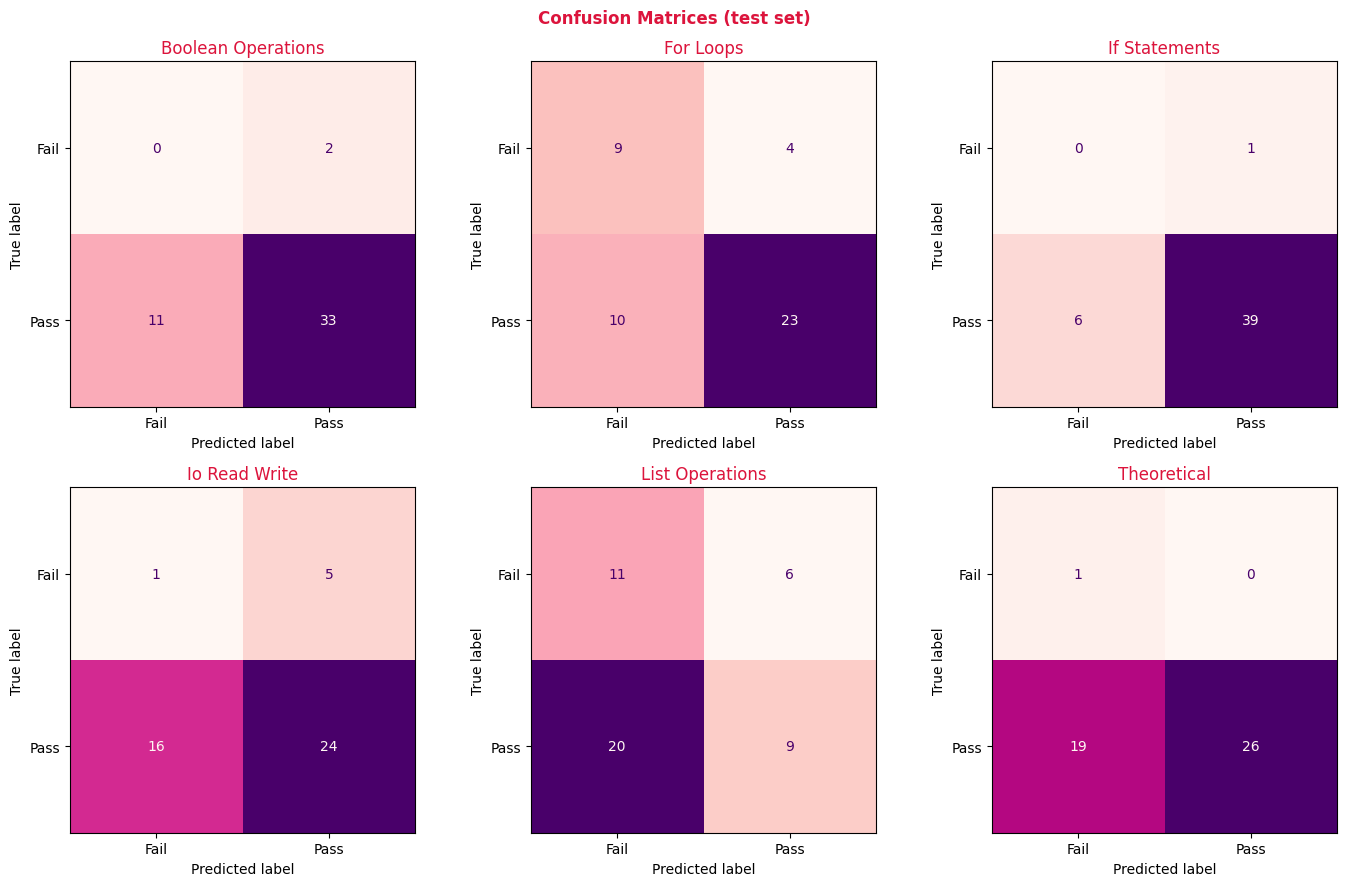

In [58]:
# ROC curves and confusion matrices
valid    = list(test_results.keys())
cols_r   = 3
rows_r   = (len(valid) + cols_r - 1) // cols_r

for plot_title, do_roc in [("ROC Curves", True),
                            ("Confusion Matrices", False)]:
    fig, axes = plt.subplots(rows_r, cols_r,
                             figsize=(14, rows_r * 4.5))
    axes = axes.flatten()
    fig.suptitle(f'{plot_title} (test set)',
                 color='crimson', fontweight='bold')

    for ax, concept in zip(axes, valid):
        y_tr  = (y_train_all[concept] >= 0.5).astype(int)
        y_te  = (y_test_all[concept]  >= 0.5).astype(int)
        pen   = penalty_selection[concept]
        model = LogisticRegression(
            penalty=pen, solver=solvers[pen],
            class_weight='balanced', max_iter=1000)
        model.fit(X_train_scaled, y_tr)

        if do_roc:
            RocCurveDisplay.from_estimator(
                model, X_test_scaled, y_te, ax=ax, color='hotpink')
            ax.plot([0,1],[0,1],'k--', linewidth=0.8)
        else:
            cm = confusion_matrix(y_te, model.predict(X_test_scaled))
            ConfusionMatrixDisplay(
                cm, display_labels=['Fail','Pass']
            ).plot(ax=ax, colorbar=False, cmap='RdPu')
        ax.set_title(concept.replace('_',' ').title(), color='crimson')

    for ax in axes[len(valid):]:
        ax.set_visible(False)
    plt.tight_layout(); plt.show()

### 7.5 Coefficients and Odds Ratios

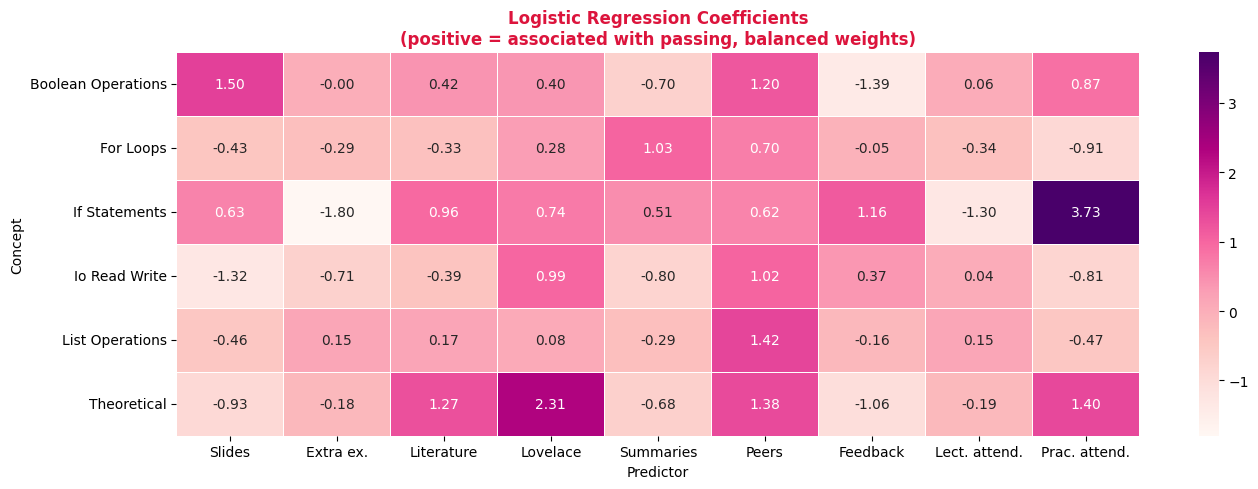

In [59]:
coef_results = {}
for concept, pen in penalty_selection.items():
    y_tr  = (y_train_all[concept] >= 0.5).astype(int)
    model = LogisticRegression(penalty=pen, solver=solvers[pen],
                               class_weight='balanced', max_iter=1000)
    model.fit(X_train_scaled, y_tr)
    coef_results[concept.replace('_',' ').title()] = dict(
        zip(predictor_labels, model.coef_[0]))

coef_df = pd.DataFrame(coef_results).T

plt.figure(figsize=(14, 5))
sns.heatmap(coef_df, annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5)
plt.title('Logistic Regression Coefficients\n'
          '(positive = associated with passing, balanced weights)',
          color='crimson', fontweight='bold')
plt.ylabel('Concept'); plt.xlabel('Predictor')
plt.tight_layout(); plt.show()

In [60]:
# p-values and odds ratios
X_sm = sm.add_constant(merged[predictor_cols].fillna(0))

for concept in valid:
    y = (merged[concept] >= 0.5).astype(int)
    if y.nunique() < 2 or y.sum() < 5 or (len(y)-y.sum()) < 5:
        continue
    try:
        fit = sm.Logit(y, X_sm).fit(disp=0)
        ci  = fit.conf_int()
        ci.columns = ['2.5%', '97.5%']
        ci['OR']    = np.exp(fit.params)
        ci['OR_lo'] = np.exp(ci['2.5%'])
        ci['OR_hi'] = np.exp(ci['97.5%'])
        ci['p']     = fit.pvalues
        ci['sig']   = ci['p'].apply(
            lambda p: '***' if p<0.001 else
                      '**'  if p<0.01  else
                      '*'   if p<0.05  else '')
        print(f"\n{concept.replace('_',' ').title()}")
        print(ci[['OR','OR_lo','OR_hi','p','sig']].round(3).to_string())
    except Exception as e:
        print(f"  {concept}: {e}")


Boolean Operations
                               OR  OR_lo    OR_hi      p sig
const                1.841700e+01  2.582  131.358  0.004  **
used_slides          2.374000e+00  0.513   10.989  0.269    
used_extra_ex        4.010000e-01  0.085    1.885  0.247    
used_literature      8.290000e-01  0.079    8.738  0.876    
used_lovelace        2.424000e+00  0.254   23.144  0.442    
used_summaries       9.410000e-01  0.064   13.934  0.965    
used_peers           7.400297e+10  0.000      inf  1.000    
used_feedback        3.680000e-01  0.051    2.655  0.321    
lecture_attendance   1.075000e+00  0.622    1.859  0.795    
practice_attendance  9.350000e-01  0.502    1.740  0.831    

For Loops
                        OR  OR_lo   OR_hi      p  sig
const                8.429  3.211  22.126  0.000  ***
used_slides          0.600  0.297   1.212  0.154     
used_extra_ex        0.848  0.412   1.747  0.655     
used_literature      0.563  0.220   1.444  0.232     
used_lovelace        1.895  

### 7.6 Chi-Square and Point-Biserial Correlation Tests

In [61]:
chi2_results = {}
for concept in concept_names:
    y = (merged[concept] >= 0.5).astype(int)
    if y.nunique() < 2:
        continue
    concept_res = {}
    for col, label in zip(predictor_cols, predictor_labels):
        if merged[col].nunique() <= 2:
            ct = pd.crosstab(merged[col], y)
            if ct.shape == (2, 2):
                chi2, p, _, _ = chi2_contingency(ct)
                concept_res[label] = {'stat': round(chi2,3),
                                      'p': round(p,3), 'test': 'χ²'}
        else:
            r, p = pointbiserialr(merged[col].fillna(0), y)
            concept_res[label] = {'stat': round(r,3),
                                  'p': round(p,3), 'test': 'r_pb'}
    chi2_results[concept] = concept_res

for concept, res in chi2_results.items():
    sig = {k: v for k, v in res.items() if v['p'] < 0.05}
    print(f"\n{concept.replace('_',' ').title()}")
    if sig:
        for pred, vals in sig.items():
            print(f"  * {pred:20s}  {vals['test']}={vals['stat']:+.3f}  p={vals['p']:.3f}")
    else:
        print("  No significant associations at p < 0.05")


Boolean Operations
  No significant associations at p < 0.05

For Loops
  * Lect. attend.         r_pb=-0.149  p=0.025
  * Prac. attend.         r_pb=-0.141  p=0.034

Functions
  No significant associations at p < 0.05

If Statements
  No significant associations at p < 0.05

Io Read Write
  * Slides                χ²=+4.104  p=0.043

List Operations
  No significant associations at p < 0.05

Operations And Types
  No significant associations at p < 0.05

Theoretical
  No significant associations at p < 0.05

Theoretical With Examples
  No significant associations at p < 0.05


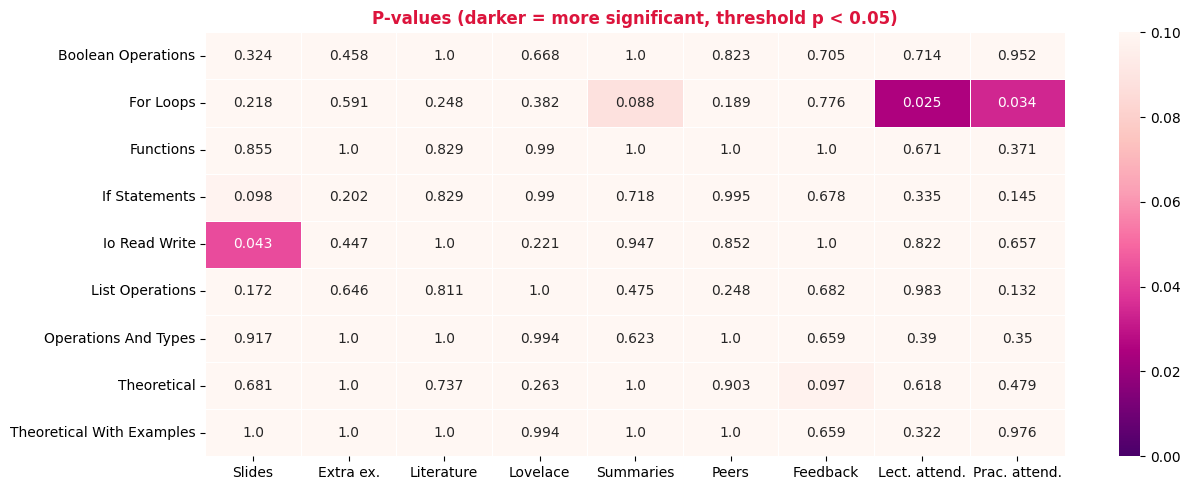

In [62]:
# p-value heatmap
p_matrix = pd.DataFrame({
    concept: {label: chi2_results.get(concept,{}).get(label,{}).get('p', np.nan)
              for label in predictor_labels}
    for concept in concept_names
}).T

plt.figure(figsize=(13, 5))
sns.heatmap(p_matrix.astype(float),
            annot=p_matrix.round(3).astype(str),
            fmt='', cmap='RdPu_r',
            xticklabels=predictor_labels,
            yticklabels=[c.replace('_',' ').title() for c in p_matrix.index],
            linewidths=0.5, vmin=0, vmax=0.1)
plt.title('P-values (darker = more significant, threshold p < 0.05)',
          color='crimson', fontweight='bold')
plt.tight_layout(); plt.show()

### 7.7 Logistic Regression Summary

In [63]:
print("Logistic regression summary")

print("\nCross-validated (training set):")
for m in ['accuracy','precision','recall','f1','roc_auc']:
    print(f"  Mean {m:12s}: {cv_df[m].mean():.3f}")

print("\nTest set:")
for m in ['accuracy','precision','recall','f1','roc_auc']:
    print(f"  Mean {m:12s}: {test_df[m].mean():.3f}")

print("\nTop predictor per concept (by coefficient):")
for concept in coef_df.index:
    top = coef_df.loc[concept].abs().idxmax()
    val = coef_df.loc[concept, top]
    print(f"  {concept:35s}  {top} ({val:+.2f})")

Logistic regression summary

Cross-validated (training set):
  Mean accuracy    : 0.633
  Mean precision   : 0.512
  Mean recall      : 0.525
  Mean f1          : 0.473
  Mean roc_auc     : 0.559

Test set:
  Mean accuracy    : 0.638
  Mean precision   : 0.511
  Mean recall      : 0.526
  Mean f1          : 0.464
  Mean roc_auc     : 0.581

Top predictor per concept (by coefficient):
  Boolean Operations                   Slides (+1.50)
  For Loops                            Summaries (+1.03)
  If Statements                        Prac. attend. (+3.73)
  Io Read Write                        Slides (-1.32)
  List Operations                      Peers (+1.42)
  Theoretical                          Lovelace (+2.31)


## 8. Model 2 - Linear Regression (Continuous Concept Score)

**Predictors:** same nine predictors as the logistic regression model,
same scaling and train/test split.

**Metrics:**
- **R²** - proportion of variance explained. R² = 0 means the model does no
  better than predicting the mean for every student; negative R² means it is
  worse than that baseline.
- **MAE** - average absolute error. On a 0–1 scale this is directly
  interpretable: MAE = 0.1 means predictions are on average 0.1 from the true score.

**Statistical significance:** OLS from statsmodels provides p-values and
confidence intervals for each coefficient.

In [64]:
cv_lin = KFold(n_splits=5, shuffle=True, random_state=42)

lin_cv_results = {}
for concept in concept_names:
    y_tr = y_train_all[concept].fillna(y_train_all[concept].mean())
    res  = cross_validate(
        LinearRegression(), X_train_scaled, y_tr, cv=cv_lin,
        scoring=['r2', 'neg_mean_absolute_error'])
    lin_cv_results[concept] = {
        'R²':  round(res['test_r2'].mean(), 3),
        'MAE': round(-res['test_neg_mean_absolute_error'].mean(), 3),
    }

lin_cv_df = pd.DataFrame(lin_cv_results).T
print("Linear Regression — Cross-validated (training set):")
print(lin_cv_df.to_string())

Linear Regression — Cross-validated (training set):
                              R²    MAE
boolean_operations        -0.071  0.154
for_loops                  0.047  0.246
functions                 -0.097  0.159
if_statements             -0.079  0.180
io_read_write             -0.029  0.181
list_operations           -0.111  0.275
operations_and_types      -0.202  0.091
theoretical               -0.204  0.149
theoretical_with_examples -0.070  0.149


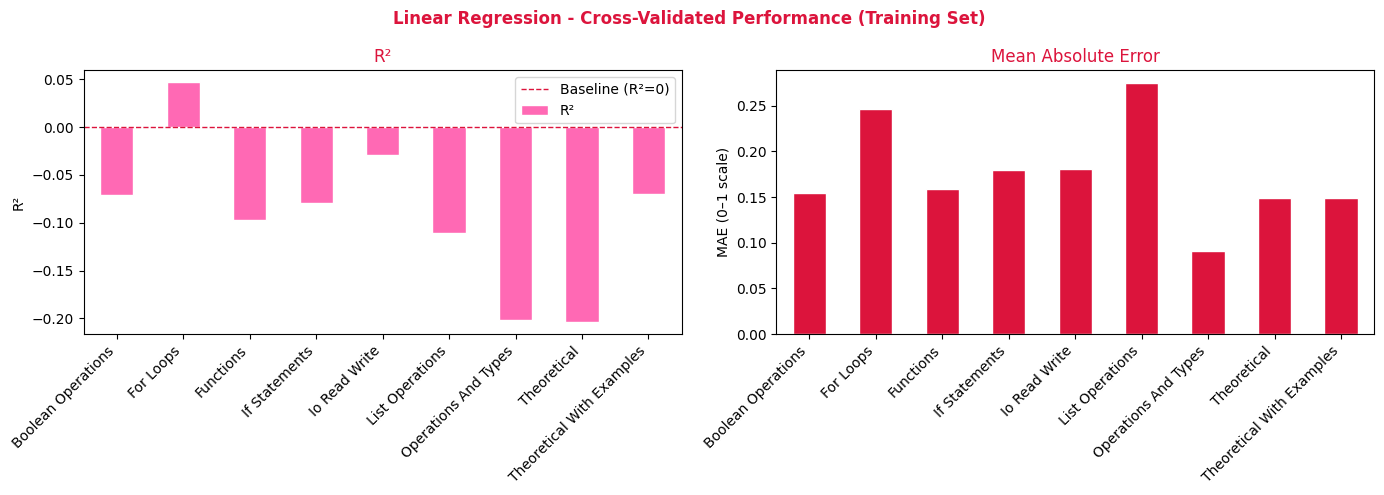

In [65]:
concept_labels_lin = [c.replace('_',' ').title() for c in lin_cv_df.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Linear Regression - Cross-Validated Performance (Training Set)',
             color='crimson', fontweight='bold')

lin_cv_df['R²'].plot.bar(ax=axes[0], color='hotpink', edgecolor='white')
axes[0].set_title('R²', color='crimson'); axes[0].set_ylabel('R²')
axes[0].axhline(0, color='crimson', linestyle='--', linewidth=1,
                label='Baseline (R²=0)')
axes[0].set_xticklabels(concept_labels_lin, rotation=45, ha='right')
axes[0].legend()

lin_cv_df['MAE'].plot.bar(ax=axes[1], color='crimson', edgecolor='white')
axes[1].set_title('Mean Absolute Error', color='crimson')
axes[1].set_ylabel('MAE (0–1 scale)')
axes[1].set_xticklabels(concept_labels_lin, rotation=45, ha='right')

plt.tight_layout(); plt.show()

### 8.1 Test Set Evaluation

In [66]:
lin_test_results = {}
lin_models       = {}

for concept in concept_names:
    y_tr   = y_train_all[concept].fillna(y_train_all[concept].mean())
    y_te   = y_test_all[concept].fillna(y_test_all[concept].mean())
    model  = LinearRegression()
    model.fit(X_train_scaled, y_tr)
    y_pred = model.predict(X_test_scaled)

    lin_test_results[concept] = {
        'R²':  round(r2_score(y_te, y_pred), 3),
        'MAE': round(mean_absolute_error(y_te, y_pred), 3),
    }
    lin_models[concept] = (model, y_te, y_pred)

lin_test_df = pd.DataFrame(lin_test_results).T
print("Test set performance:")
print(lin_test_df.to_string())

Test set performance:
                              R²    MAE
boolean_operations        -0.131  0.169
for_loops                  0.168  0.217
functions                 -0.014  0.159
if_statements             -0.110  0.198
io_read_write              0.050  0.164
list_operations           -0.084  0.284
operations_and_types       0.093  0.076
theoretical               -0.104  0.118
theoretical_with_examples -0.170  0.142


### 8.2 Residual Analysis

Residuals should be randomly distributed around zero if linear regression
assumptions hold. Systematic patterns (such as residuals increasing with
fitted values) suggest a non-linear relationship or omitted predictors.

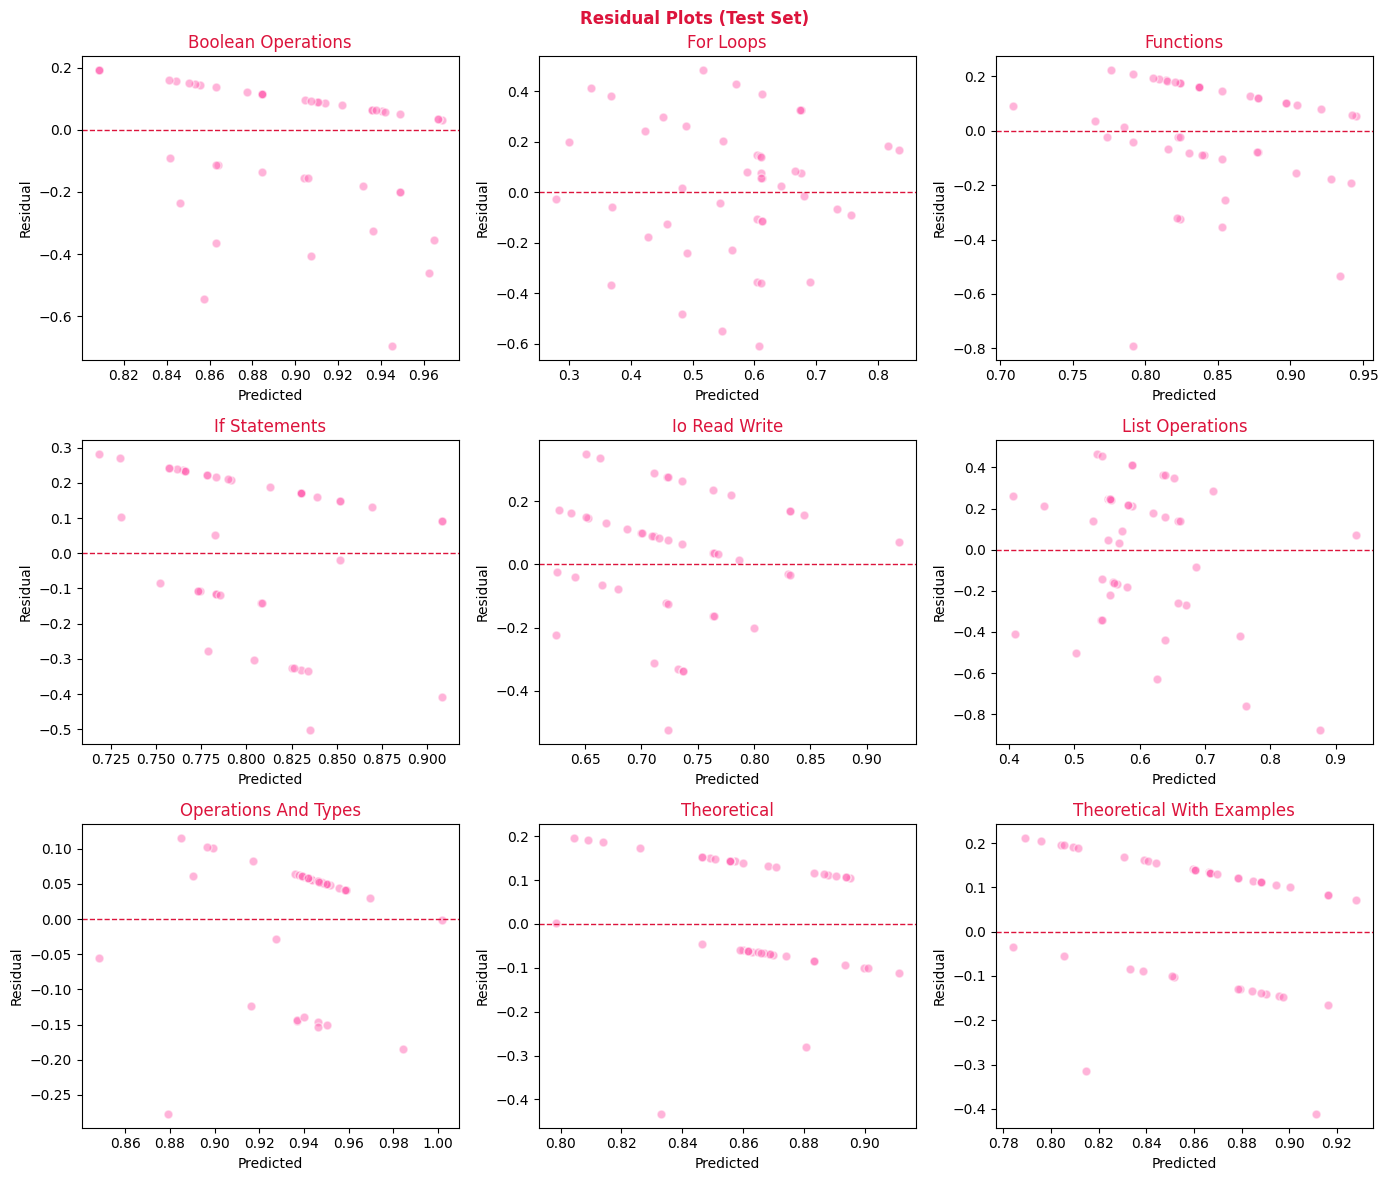

In [67]:
rows_r = (len(concept_names) + 2) // 3

fig, axes = plt.subplots(rows_r, 3, figsize=(14, rows_r * 4))
axes = axes.flatten()
fig.suptitle('Residual Plots (Test Set)', color='crimson', fontweight='bold')

for ax, concept in zip(axes, concept_names):
    _, y_te, y_pred = lin_models[concept]
    residuals = y_te.values - y_pred
    ax.scatter(y_pred, residuals, color='hotpink',
               alpha=0.5, edgecolors='white', s=40)
    ax.axhline(0, color='crimson', linestyle='--', linewidth=1)
    ax.set_title(concept.replace('_',' ').title(), color='crimson')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')

for ax in axes[len(concept_names):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

### 8.3 Predicted vs Actual

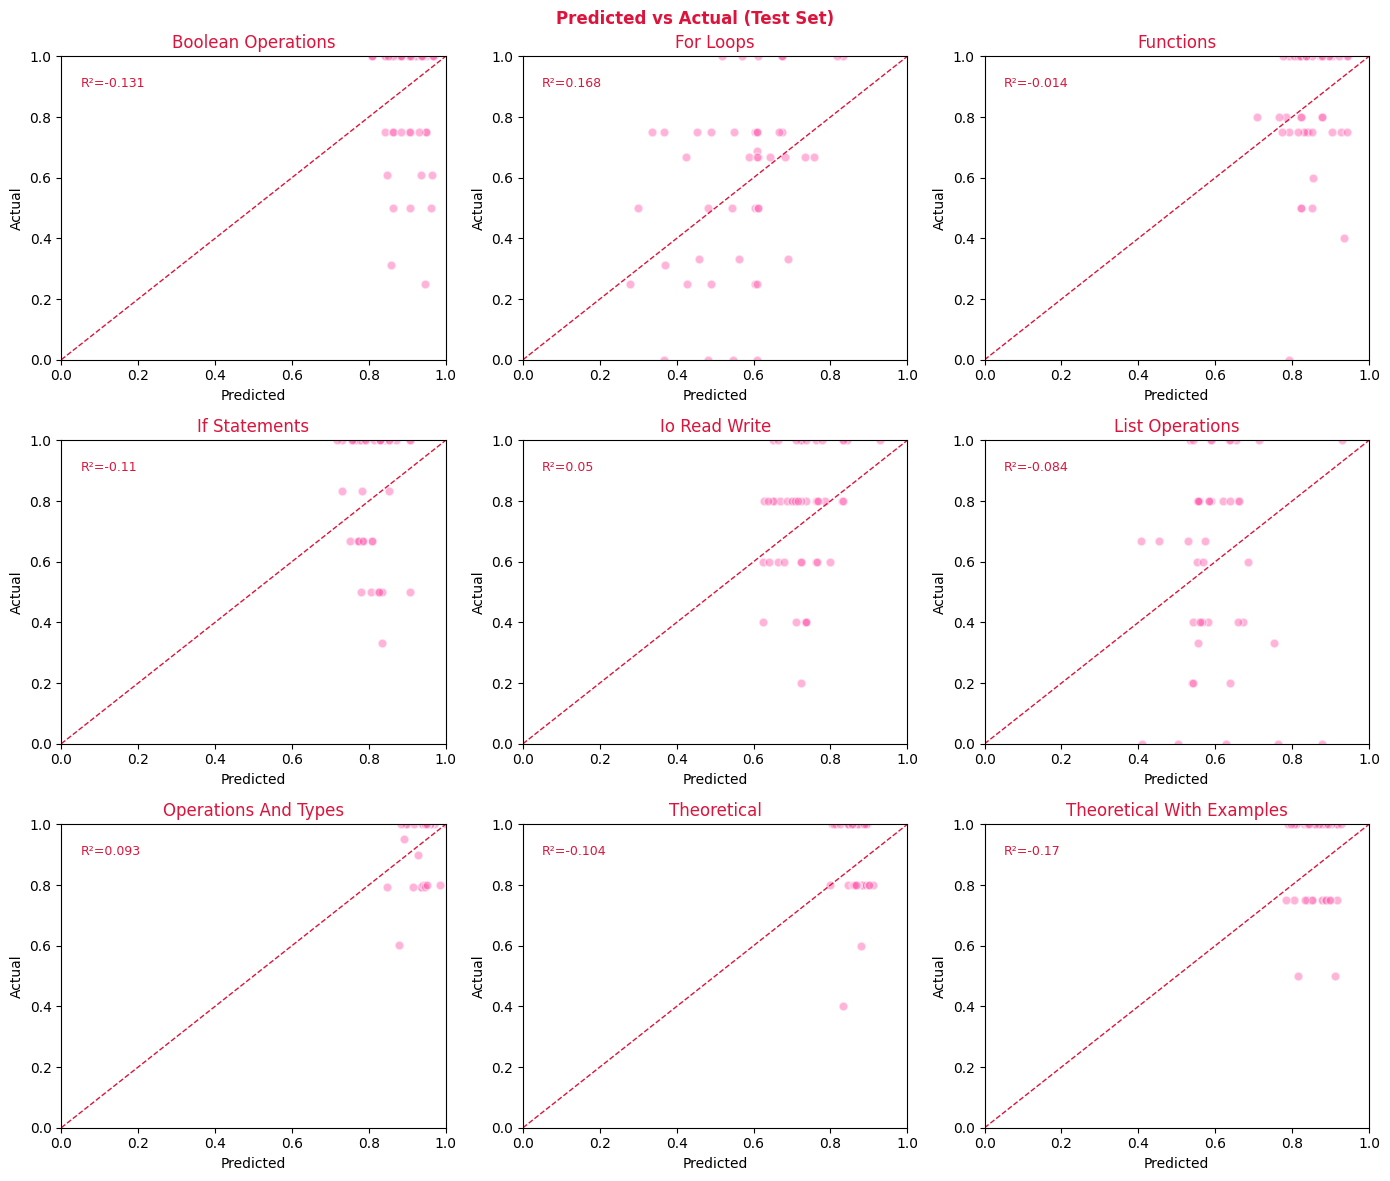

In [68]:
fig, axes = plt.subplots(rows_r, 3, figsize=(14, rows_r * 4))
axes = axes.flatten()
fig.suptitle('Predicted vs Actual (Test Set)', color='crimson', fontweight='bold')

for ax, concept in zip(axes, concept_names):
    _, y_te, y_pred = lin_models[concept]
    ax.scatter(y_pred, y_te.values, color='hotpink',
               alpha=0.5, edgecolors='white', s=40)
    ax.plot([0,1],[0,1], color='crimson', linestyle='--', linewidth=1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_title(concept.replace('_',' ').title(), color='crimson')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.text(0.05, 0.9, f"R²={lin_test_results[concept]['R²']}",
            transform=ax.transAxes, color='crimson', fontsize=9)

for ax in axes[len(concept_names):]:
    ax.set_visible(False)
plt.tight_layout(); plt.show()

### 8.4 Coefficient Heatmap

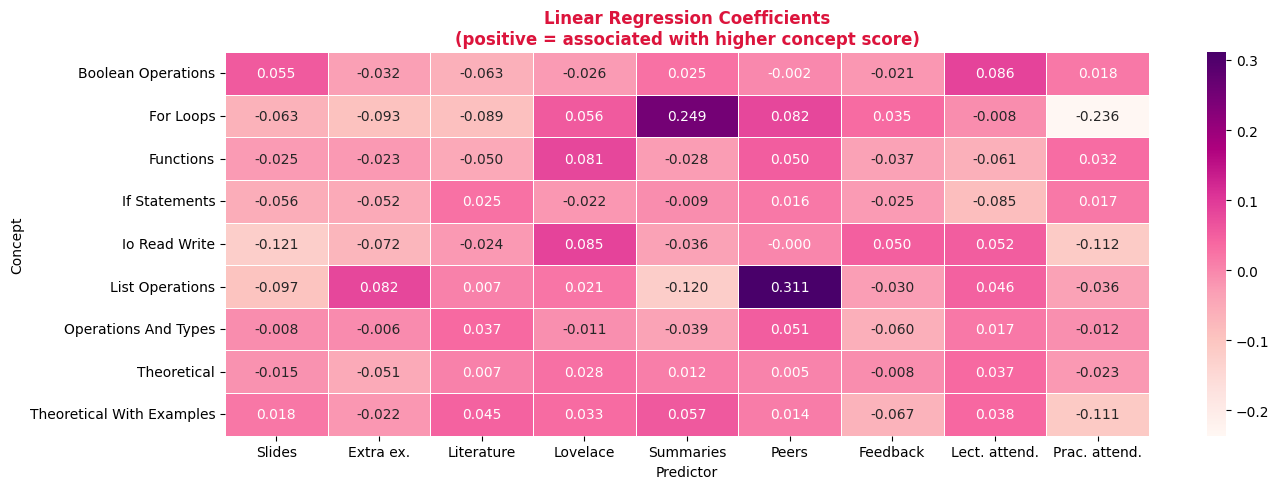

In [69]:
lin_coef_results = {}
for concept in concept_names:
    y_tr  = y_train_all[concept].fillna(y_train_all[concept].mean())
    model = LinearRegression()
    model.fit(X_train_scaled, y_tr)
    lin_coef_results[concept.replace('_',' ').title()] = dict(
        zip(predictor_labels, model.coef_))

lin_coef_df = pd.DataFrame(lin_coef_results).T

plt.figure(figsize=(14, 5))
sns.heatmap(lin_coef_df, annot=True, fmt='.3f', cmap='RdPu', linewidths=0.5)
plt.title('Linear Regression Coefficients\n'
          '(positive = associated with higher concept score)',
          color='crimson', fontweight='bold')
plt.ylabel('Concept'); plt.xlabel('Predictor')
plt.tight_layout(); plt.show()

### 8.5 Ordinary Least Squares (OLS) - P-values and Confidence Intervals

In [70]:
X_sm_ols = sm.add_constant(merged[predictor_cols].fillna(0))
ols_results = {}

for concept in concept_names:
    y = merged[concept].fillna(merged[concept].mean())
    try:
        ols = sm.OLS(y, X_sm_ols).fit()
        ci  = ols.conf_int()
        ci.columns = ['2.5%', '97.5%']
        ci['coef'] = ols.params
        ci['p']    = ols.pvalues
        ci['sig']  = ci['p'].apply(
            lambda p: '***' if p<0.001 else
                      '**'  if p<0.01  else
                      '*'   if p<0.05  else '')
        ols_results[concept] = ci
        print(f"\n{concept.replace('_',' ').title()}  "
              f"R²={ols.rsquared:.3f}, adj.R²={ols.rsquared_adj:.3f}")
        print(ci[['coef','2.5%','97.5%','p','sig']].round(3).to_string())
    except Exception as e:
        print(f"  {concept}: {e}")


Boolean Operations  R²=0.047, adj.R²=0.007
                      coef   2.5%  97.5%      p  sig
const                0.806  0.730  0.881  0.000  ***
used_slides          0.039 -0.019  0.097  0.191     
used_extra_ex       -0.028 -0.092  0.035  0.380     
used_literature     -0.062 -0.146  0.022  0.146     
used_lovelace        0.002 -0.060  0.064  0.952     
used_summaries       0.018 -0.075  0.111  0.701     
used_peers           0.031 -0.066  0.127  0.535     
used_feedback        0.002 -0.079  0.083  0.955     
lecture_attendance   0.020  0.001  0.039  0.040    *
practice_attendance -0.006 -0.028  0.015  0.573     

For Loops  R²=0.167, adj.R²=0.133
                      coef   2.5%  97.5%      p  sig
const                0.764  0.653  0.874  0.000  ***
used_slides         -0.075 -0.160  0.010  0.083     
used_extra_ex       -0.051 -0.143  0.042  0.284     
used_literature     -0.103 -0.226  0.020  0.099     
used_lovelace        0.079 -0.012  0.169  0.088     
used_summaries      

### 8.6 Model Comparison - Logistic vs Linear Coefficients

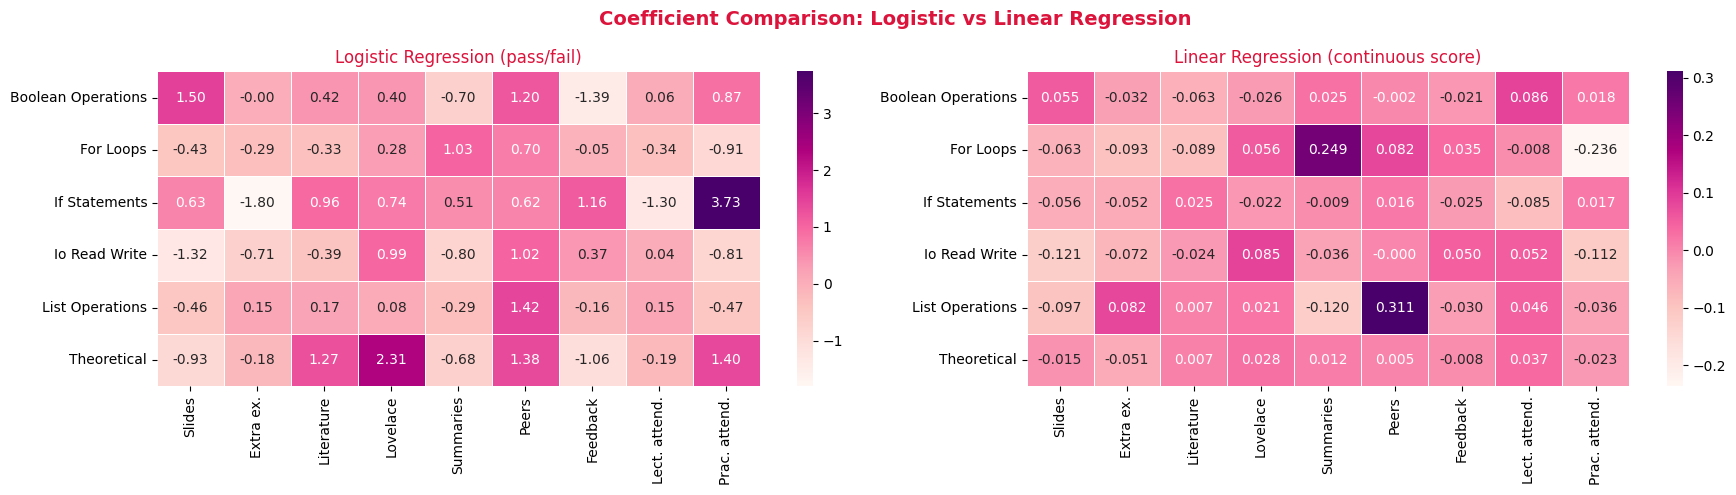

In [71]:
shared_index = [c for c in coef_df.index if c in lin_coef_df.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Coefficient Comparison: Logistic vs Linear Regression',
             color='crimson', fontweight='bold', fontsize=14)

sns.heatmap(coef_df.loc[shared_index], annot=True, fmt='.2f',
            cmap='RdPu', linewidths=0.5, ax=axes[0])
axes[0].set_title('Logistic Regression (pass/fail)', color='crimson')

sns.heatmap(lin_coef_df.loc[shared_index], annot=True, fmt='.3f',
            cmap='RdPu', linewidths=0.5, ax=axes[1])
axes[1].set_title('Linear Regression (continuous score)', color='crimson')

plt.tight_layout(); plt.show()

### 8.7 Linear Regression Summary

In [72]:
print("Linear regression summary")

print("\nCross-validated (training set):")
print(f"  Mean R²:  {lin_cv_df['R²'].mean():.3f}")
print(f"  Mean MAE: {lin_cv_df['MAE'].mean():.3f}")
print(f"  Best R²:  {lin_cv_df['R²'].idxmax()} "
      f"({lin_cv_df['R²'].max():.3f})")
print(f"  Worst R²: {lin_cv_df['R²'].idxmin()} "
      f"({lin_cv_df['R²'].min():.3f})")

print("\nTest set:")
print(f"  Mean R²:  {lin_test_df['R²'].mean():.3f}")
print(f"  Mean MAE: {lin_test_df['MAE'].mean():.3f}")
print(f"  Best R²:  {lin_test_df['R²'].idxmax()} "
      f"({lin_test_df['R²'].max():.3f})")

print("\nTop predictor per concept (by coefficient):")
for concept in lin_coef_df.index:
    top = lin_coef_df.loc[concept].abs().idxmax()
    val = lin_coef_df.loc[concept, top]
    print(f"  {concept:35s}  {top} ({val:+.3f})")

print("\nSignificant OLS predictors (p < 0.05):")
for concept, ci in ols_results.items():
    sig = ci[(ci['sig'] != '') & (ci.index != 'const')]
    if not sig.empty:
        print(f"\n  {concept.replace('_',' ').title()}")
        for pred, row in sig.iterrows():
            print(f"    {pred:20s}  coef={row['coef']:+.3f}  "
                  f"p={row['p']:.3f} {row['sig']}")
    else:
        print(f"\n  {concept.replace('_',' ').title()} "
              f"- no significant predictors")

Linear regression summary

Cross-validated (training set):
  Mean R²:  -0.091
  Mean MAE: 0.176
  Best R²:  for_loops (0.047)
  Worst R²: theoretical (-0.204)

Test set:
  Mean R²:  -0.034
  Mean MAE: 0.170
  Best R²:  for_loops (0.168)

Top predictor per concept (by coefficient):
  Boolean Operations                   Lect. attend. (+0.086)
  For Loops                            Summaries (+0.249)
  Functions                            Lovelace (+0.081)
  If Statements                        Lect. attend. (-0.085)
  Io Read Write                        Slides (-0.121)
  List Operations                      Peers (+0.311)
  Operations And Types                 Feedback (-0.060)
  Theoretical                          Extra ex. (-0.051)
  Theoretical With Examples            Prac. attend. (-0.111)

Significant OLS predictors (p < 0.05):

  Boolean Operations
    lecture_attendance    coef=+0.020  p=0.040 *

  For Loops
    used_summaries        coef=+0.253  p=0.000 ***
    practice_atten